# Final Demo and Single-Image Inference

This notebook demonstrates the finished anomaly-detection pipeline.

It loads the saved feature-based detector and runs inference on individual
MVTec bottle images.

The detector outputs:

- normal/defective prediction,
- anomaly score,
- anomaly heatmap,
- binary predicted defect mask,
- heatmap overlay,
- mask overlay.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

PROJECT_ROOT = Path(r"D:\PROJECTS\ANOMALY DETECTION")
DATASET_ROOT = PROJECT_ROOT / "data" / "raw" / "mvtec_ad"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.inference.single_image_inference import (
    IndustrialAnomalyInference,
)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

MEMORY_BANK_PATH = (
    PROJECT_ROOT
    / "models"
    / "resnet18_memory_bank_bottle.pt"
)

CONFIGURATION_PATH = (
    PROJECT_ROOT
    / "models"
    / "feature_detector_bottle_config.json"
)

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)
print("Memory bank exists:", MEMORY_BANK_PATH.exists())
print("Config exists:", CONFIGURATION_PATH.exists())

Project root: D:\PROJECTS\ANOMALY DETECTION
Device: cuda
Memory bank exists: True
Config exists: True


In [2]:
inference_engine = IndustrialAnomalyInference(
    memory_bank_path=MEMORY_BANK_PATH,
    configuration_path=CONFIGURATION_PATH,
    device=DEVICE,
)

print("Inference engine loaded.")
print("Image size:", inference_engine.image_size)
print(
    "Image threshold:",
    inference_engine.detector.image_score_threshold,
)
print(
    "Pixel threshold:",
    inference_engine.detector.pixel_threshold,
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Admin/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:03<00:00, 14.7MB/s]


Inference engine loaded.
Image size: 256
Image threshold: 0.7190231680870056
Pixel threshold: 0.6153336763381958


In [3]:
sample_paths = {
    "normal": (
        DATASET_ROOT
        / "bottle"
        / "test"
        / "good"
        / "000.png"
    ),
    "broken_large": (
        DATASET_ROOT
        / "bottle"
        / "test"
        / "broken_large"
        / "000.png"
    ),
    "broken_small": (
        DATASET_ROOT
        / "bottle"
        / "test"
        / "broken_small"
        / "000.png"
    ),
    "contamination": (
        DATASET_ROOT
        / "bottle"
        / "test"
        / "contamination"
        / "000.png"
    ),
}

for name, path in sample_paths.items():
    print(f"{name:<15}: {path.exists()} | {path}")

normal         : True | D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_ad\bottle\test\good\000.png
broken_large   : True | D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_ad\bottle\test\broken_large\000.png
broken_small   : True | D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_ad\bottle\test\broken_small\000.png
contamination  : True | D:\PROJECTS\ANOMALY DETECTION\data\raw\mvtec_ad\bottle\test\contamination\000.png


In [6]:
predictions = {}

for name, image_path in sample_paths.items():
    prediction = inference_engine.predict_image(
        image_path
    )

    predictions[name] = prediction

    print(name)
    print("Prediction:", prediction["prediction_text"])
    print(
        "Score:",
        f"{prediction['image_score']:.6f}",
    )
    print(
        "Threshold:",
        f"{prediction['image_threshold']:.6f}",
    )
    print("\n")

normal
Prediction: normal
Score: 0.664207
Threshold: 0.719023


broken_large
Prediction: defective
Score: 0.949342
Threshold: 0.719023


broken_small
Prediction: defective
Score: 0.829157
Threshold: 0.719023


contamination
Prediction: defective
Score: 0.869325
Threshold: 0.719023




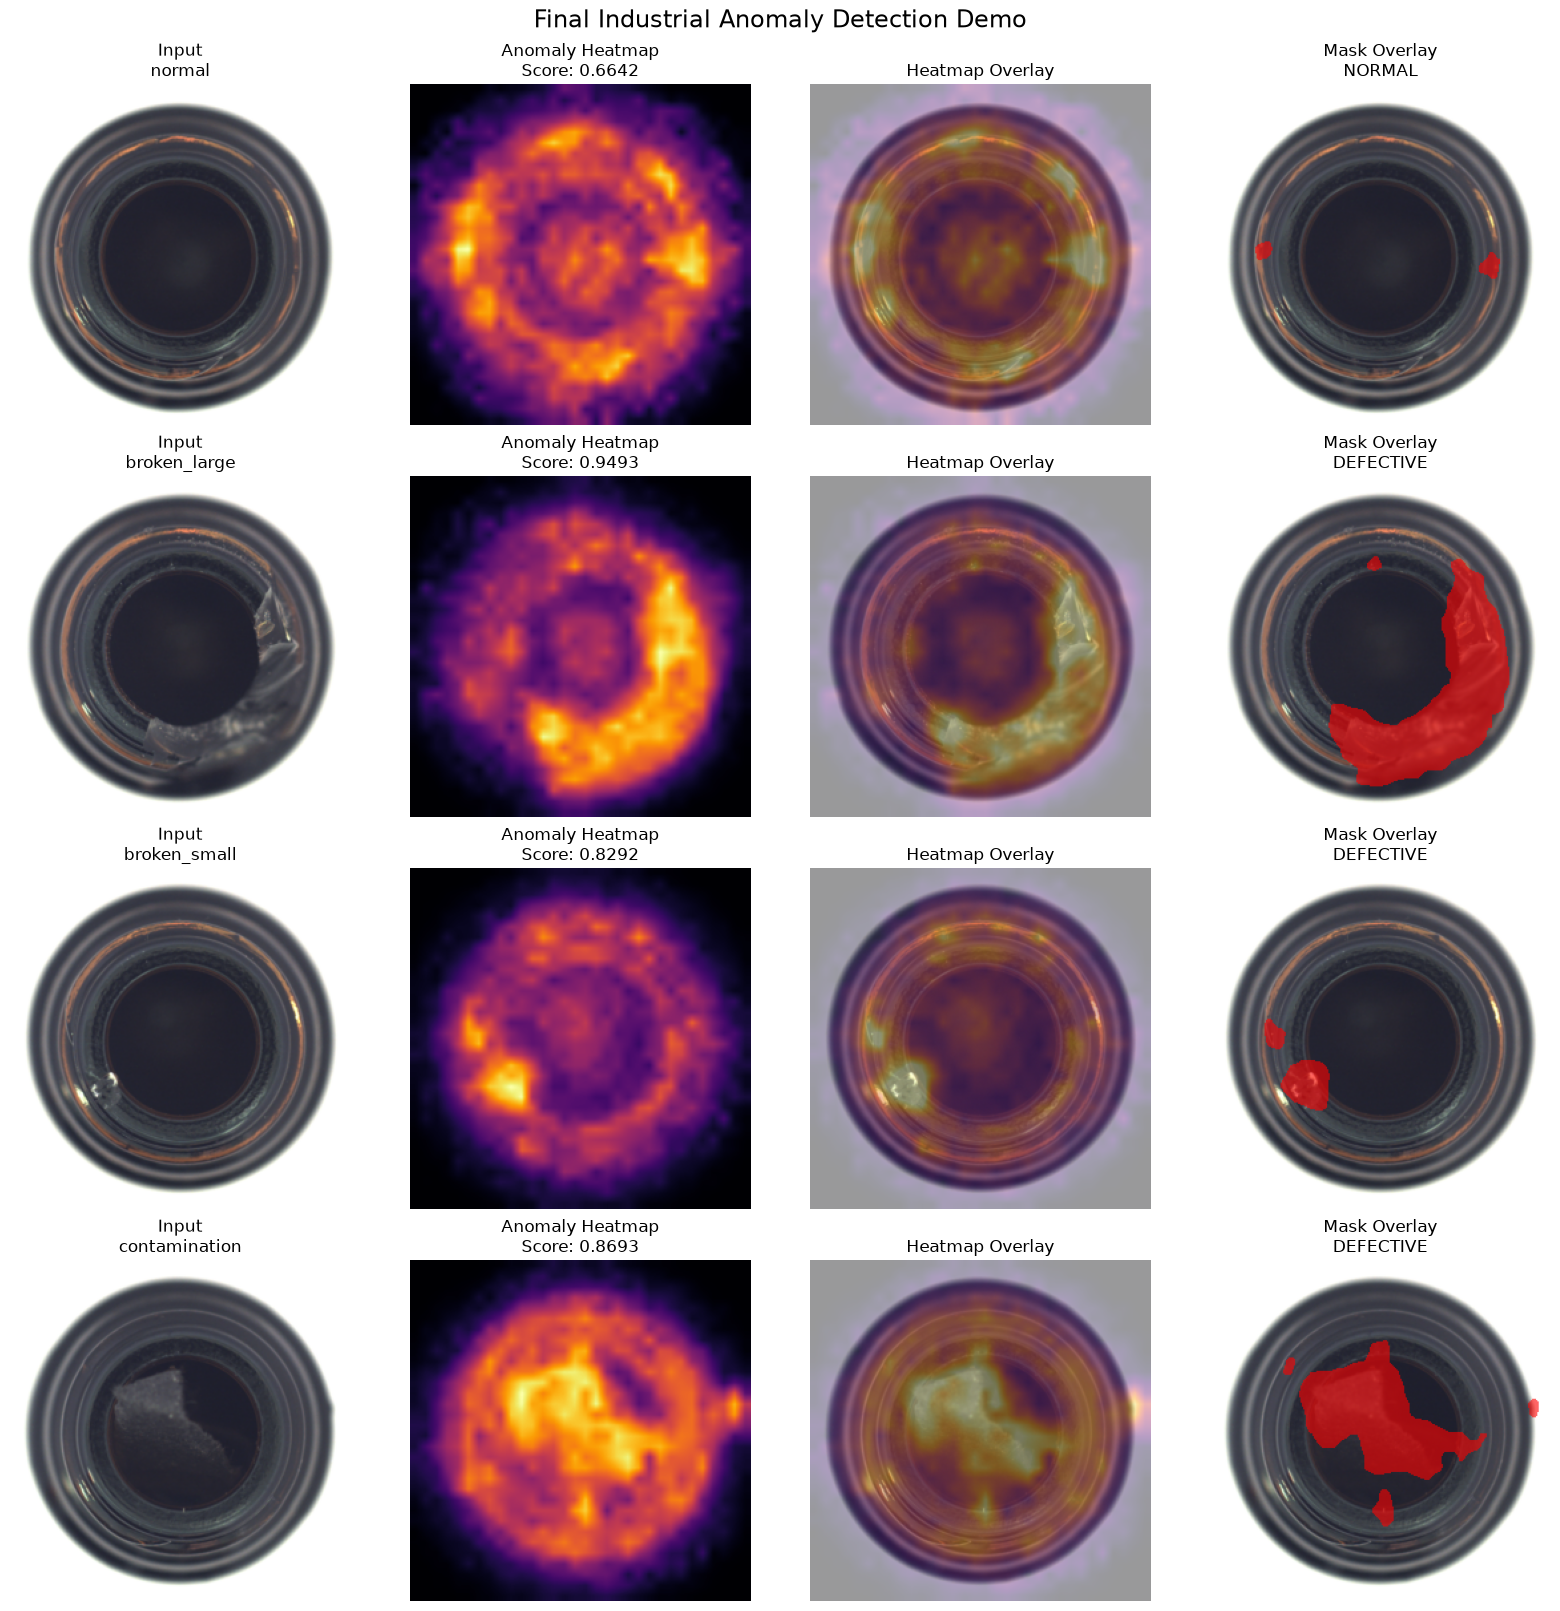

Demo figure saved to:
D:\PROJECTS\ANOMALY DETECTION\results\figures\final_inference_demo.png


In [8]:
number_of_samples = len(predictions)

figure, axes = plt.subplots(
    number_of_samples,
    4,
    figsize=(16, 4 * number_of_samples),
    constrained_layout=True,
)

for row_index, (name, prediction) in enumerate(
    predictions.items()
):
    axes[row_index, 0].imshow(
        prediction["resized_image"]
    )
    axes[row_index, 0].set_title(
        f"Input\n{name}"
    )
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(
        prediction["anomaly_map"],
        cmap="inferno",
    )
    axes[row_index, 1].set_title(
        "Anomaly Heatmap\n"
        f"Score: {prediction['image_score']:.4f}"
    )
    axes[row_index, 1].axis("off")

    axes[row_index, 2].imshow(
        prediction["heatmap_overlay"]
    )
    axes[row_index, 2].set_title(
        "Heatmap Overlay"
    )
    axes[row_index, 2].axis("off")

    axes[row_index, 3].imshow(
        prediction["mask_overlay"]
    )
    axes[row_index, 3].set_title(
        f"Mask Overlay\n"
        f"{prediction['prediction_text'].upper()}"
    )
    axes[row_index, 3].axis("off")

figure.suptitle(
    "Final Industrial Anomaly Detection Demo",
    fontsize=17,
)

demo_figure_path = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "final_inference_demo.png"
)

plt.savefig(
    demo_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Demo figure saved to:")
print(demo_figure_path)

In [9]:
OUTPUT_DIR = (
    PROJECT_ROOT
    / "results"
    / "demo_outputs"
)

saved_output_records = []

for name, prediction in predictions.items():
    saved_paths = inference_engine.save_prediction_outputs(
        prediction=prediction,
        output_dir=OUTPUT_DIR,
        prefix=name,
    )

    for output_type, output_path in saved_paths.items():
        saved_output_records.append(
            {
                "sample": name,
                "output_type": output_type,
                "path": str(output_path),
            }
        )

print("Saved outputs:")

for record in saved_output_records:
    print(
        f"{record['sample']:<15} "
        f"{record['output_type']:<20} "
        f"{record['path']}"
    )

Saved outputs:
normal          resized_image        D:\PROJECTS\ANOMALY DETECTION\results\demo_outputs\normal_resized_image.png
normal          heatmap_overlay      D:\PROJECTS\ANOMALY DETECTION\results\demo_outputs\normal_heatmap_overlay.png
normal          mask_overlay         D:\PROJECTS\ANOMALY DETECTION\results\demo_outputs\normal_mask_overlay.png
normal          processed_mask       D:\PROJECTS\ANOMALY DETECTION\results\demo_outputs\normal_processed_mask.png
broken_large    resized_image        D:\PROJECTS\ANOMALY DETECTION\results\demo_outputs\broken_large_resized_image.png
broken_large    heatmap_overlay      D:\PROJECTS\ANOMALY DETECTION\results\demo_outputs\broken_large_heatmap_overlay.png
broken_large    mask_overlay         D:\PROJECTS\ANOMALY DETECTION\results\demo_outputs\broken_large_mask_overlay.png
broken_large    processed_mask       D:\PROJECTS\ANOMALY DETECTION\results\demo_outputs\broken_large_processed_mask.png
broken_small    resized_image        D:\PROJECTS\ANOM